# Final model comparison and held-out evaluation

### The previous notebooks identified **Logistic Regression and Random Forest** as the two models worth investigating in depth.

### This final notebook has three goals:

1. **Compare the two optimized approaches using nested cross-validation results obtained on the training data only.**
2. **Select the final model for each prediction scenario before looking at the held-out test set.**
3. **Evaluate the selected model once on the untouched test set and conclude on the most appropriate analytical approach.**

The two scenarios remain separated throughout the analysis:

- **Selected risk factors only** : prediction from upstream patient characteristics.
- **Selected + diagnostics** : prediction after adding screening tests such as `Hinselmann`, `Schiller` and `Citology`.

These scenarios answer different biological questions and should therefore not be interpreted as interchangeable.

The primary selection metric remains **Average Precision (AP, used here as PR-AUC)** because the positive biopsy class is rare. MCC, recall, precision, F1-score, balanced accuracy and ROC-AUC are used as complementary metrics.

### 1. Imports and project paths

This notebook does not repeat hyperparameter optimization. It reuses the results and final hyperparameters obtained in the dedicated Logistic Regression and Random Forest notebooks.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score, recall_score, f1_score, balanced_accuracy_score, matthews_corrcoef, 
                             confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve)

RANDOM_STATE = 28

SELECTED_DIR = Path("../01_DATA/selected")
PLOTS_DIR = Path("../04_FIGURES")
RESULTS_DIR = Path("../05_RESULTS")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

### 2. Load nested cross-validation summaries

The model comparison must be based on the **outer nested-CV results**, not on the held-out test set to prevent the final test set from becoming another model-selection dataset.

In [20]:
lr_risk = pd.read_csv(RESULTS_DIR / "logistic_nested_cv_risk.csv", index_col=0)
lr_diag = pd.read_csv(RESULTS_DIR / "logistic_nested_cv_diag.csv", index_col=0)

rf_risk = pd.read_csv(RESULTS_DIR / "random_forest_nested_cv_risk.csv", index_col=0)
rf_diag = pd.read_csv(RESULTS_DIR / "random_forest_nested_cv_diag.csv", index_col=0)

print('Logistic Regression : Selected risk factors')
display(lr_risk.round(3))
print('Logistic Regression : Selected + diagnostics')
display(rf_risk.round(3))

print('Random Forest : Selected risk factors')
display(lr_diag.round(3))
print('Random Forest : Selected + diagnostics')
display(rf_diag.round(3))


Logistic Regression : Selected risk factors


,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.129,0.035,0.123,0.074,0.192
ROC_AUC,0.613,0.096,0.650,0.394,0.747
Recall,0.437,0.181,0.500,0.125,0.750
Precision,0.102,0.039,0.111,0.018,0.160
F1,0.161,0.060,0.171,0.032,0.250
Balanced_accuracy,0.572,0.095,0.595,0.319,0.689
MCC,0.083,0.101,0.105,-0.172,0.219


Logistic Regression : Selected + diagnostics


,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.119,0.034,0.122,0.055,0.180
ROC_AUC,0.605,0.098,0.616,0.331,0.758
Recall,0.331,0.183,0.286,0.125,0.875
Precision,0.123,0.060,0.115,0.045,0.286
F1,0.161,0.059,0.160,0.080,0.273
Balanced_accuracy,0.556,0.062,0.556,0.394,0.677
MCC,0.084,0.083,0.080,-0.108,0.217


Random Forest : Selected risk factors


,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.699,0.171,0.711,0.450,0.975
ROC_AUC,0.944,0.065,0.979,0.732,0.999
Recall,0.905,0.097,0.875,0.714,1.000
Precision,0.545,0.099,0.538,0.400,0.800
F1,0.675,0.087,0.667,0.526,0.889
Balanced_accuracy,0.925,0.049,0.915,0.825,0.991
MCC,0.674,0.090,0.659,0.509,0.886


Random Forest : Selected + diagnostics


,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.685,0.167,0.662,0.454,0.975
ROC_AUC,0.943,0.054,0.938,0.783,0.999
Recall,0.869,0.112,0.875,0.714,1.000
Precision,0.627,0.118,0.615,0.412,1.000
F1,0.722,0.095,0.737,0.526,0.923
Balanced_accuracy,0.915,0.056,0.919,0.825,0.991
MCC,0.713,0.101,0.725,0.509,0.922


The two algorithms lead to the same broad conclusion, but the contrast between the two biological scenarios is much larger than the contrast between algorithms.

For **selected risk factors only**, both models perform poorly. These values indicate that neither linear nor nonlinear modelling extracts a strong and stable predictive signal from the selected upstream risk factors.

For **selected + diagnostics**, both methods improve markedly. 

ROC-AUC is essentially identical (**0.944 vs 0.943**) for both models.

There's no large overall performance gap between the two optimized models. The dominant result is the gain obtained by adding diagnostic screening information.

### 3. Direct comparison of Logistic Regression and Random Forest

Mean performance and variability across the outer folds are compared side by side.

Average Precision is the primary criterion. However, a model is not selected from one metric alone, therefore stability, recall, MCC, model complexity and interpretability are also considered.

In [ ]:
def build_model_comparison(lr_summary, rf_summary, scenario):
    rows = []
    for model_name, summary in [("Logistic Regression", lr_summary), ("Random Forest", rf_summary)]:
        for metric in summary.index:
            rows.append({"Scenario": scenario,
                         "Model": model_name,
                         "Metric": metric,
                         "Mean": summary.loc[metric, "Mean"],
                         "Std": summary.loc[metric, "Std"],
                         "Median": summary.loc[metric, "Median"],
                         "Min": summary.loc[metric, "Min"],
                         "Max": summary.loc[metric, "Max"]})
    return pd.DataFrame(rows)

comparison = pd.concat([build_model_comparison(lr_risk, rf_risk, "Selected risk factors"), build_model_comparison(lr_diag, rf_diag, "Selected + diagnostics")], 
                       ignore_index=True)

comparison.to_csv(RESULTS_DIR / "final_nested_cv_model_comparison.csv", index=False)
comparison.head()

,Scenario,Model,Metric,Mean,Std,Median,Min,Max
0,Selected risk factors,Logistic Regression,PR_AUC,0.129384,0.035039,0.122632,0.073860,0.191736
1,Selected risk factors,Logistic Regression,ROC_AUC,0.612564,0.095961,0.649656,0.394495,0.747051
2,Selected risk factors,Logistic Regression,Recall,0.437143,0.181344,0.500000,0.125000,0.750000
3,Selected risk factors,Logistic Regression,Precision,0.102001,0.038814,0.111111,0.017857,0.160000
4,Selected risk factors,Logistic Regression,F1,0.160889,0.060289,0.171429,0.031746,0.250000


In [ ]:
def comparison_table(comparison, scenario):
    subset = comparison[comparison["Scenario"] == scenario]
    table = subset.pivot(index="Metric", columns="Model", values=["Mean", "Std"])
    return table

print("Selected risk factors")
display(comparison_table(comparison, "Selected risk factors").round(3))

print("\nSelected + diagnostics")
display(comparison_table(comparison, "Selected + diagnostics").round(3))

Selected risk factors


Mean                               Std  \
Model             Logistic Regression Random Forest Logistic Regression   
Metric                                                                    
Balanced_accuracy               0.572         0.556               0.095   
F1                              0.161         0.161               0.060   
MCC                             0.083         0.084               0.101   
PR_AUC                          0.129         0.119               0.035   
Precision                       0.102         0.123               0.039   
ROC_AUC                         0.613         0.605               0.096   
Recall                          0.437         0.331               0.181   

                                 
Model             Random Forest  
Metric                           
Balanced_accuracy         0.062  
F1                        0.059  
MCC                       0.083  
PR_AUC                    0.034  
Precision                 0.060  
ROC_AUC                   0.098  
Recall                    0.183


Selected + diagnostics


Mean                               Std  \
Model             Logistic Regression Random Forest Logistic Regression   
Metric                                                                    
Balanced_accuracy               0.925         0.915               0.049   
F1                              0.675         0.722               0.087   
MCC                             0.674         0.713               0.090   
PR_AUC                          0.699         0.685               0.171   
Precision                       0.545         0.627               0.099   
ROC_AUC                         0.944         0.943               0.065   
Recall                          0.905         0.869               0.097   

                                 
Model             Random Forest  
Metric                           
Balanced_accuracy         0.056  
F1                        0.095  
MCC                       0.101  
PR_AUC                    0.167  
Precision                 0.118  
ROC_AUC                   0.054  
Recall                    0.112

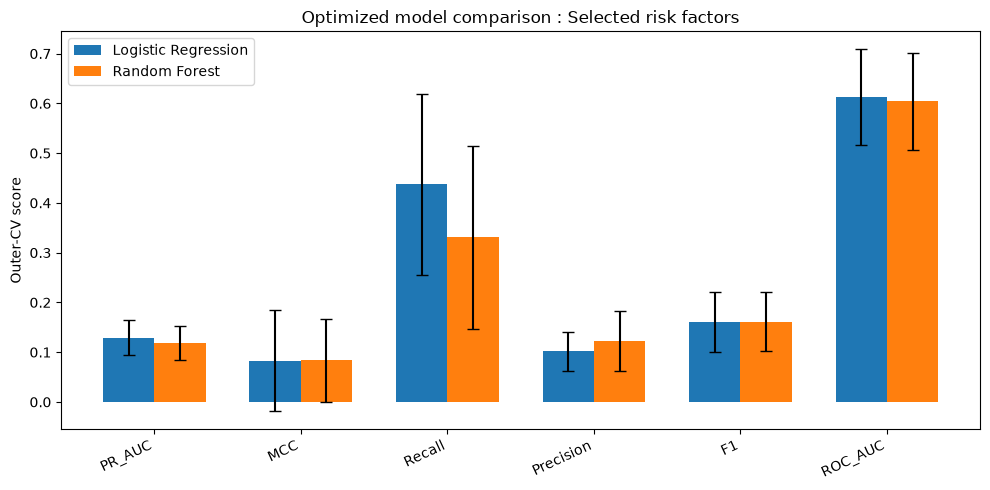

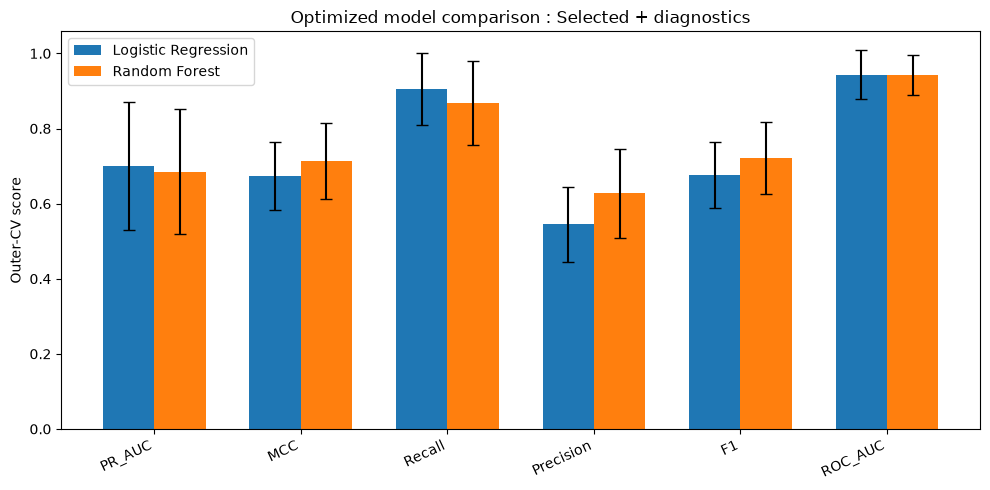

In [21]:
def plot_model_comparison(comparison, scenario, filename):
    metrics = ["PR_AUC", "MCC", "Recall", "Precision", "F1", "ROC_AUC"]
    subset = comparison[(comparison["Scenario"] == scenario) & (comparison["Metric"].isin(metrics))].copy()

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, model in enumerate(["Logistic Regression", "Random Forest"]):
        model_data = (subset[subset["Model"] == model].set_index("Metric").loc[metrics])
        offset = (i - 0.5) * width
        ax.bar(x + offset, model_data["Mean"], width, yerr=model_data["Std"], capsize=4, label=model)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=25, ha="right")
    ax.set_ylabel("Outer-CV score")
    ax.set_title(f"Optimized model comparison : {scenario}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_model_comparison(comparison, "Selected risk factors", "final_model_comparison_risk.png")
plot_model_comparison(comparison, "Selected + diagnostics", "final_model_comparison_diag.png")

The error bars strongly overlap in both scenarios, which confirms that the difference between Logistic Regression and Random Forest is small relative to the variability induced by resampling.

In the **risk-factor-only** setting, the two models remain weak regardless of their complexity. Random Forest does not provide a meaningful nonlinear advantage, supporting the idea that the main limitation is the information content of the predictors rather than the classifier itself.

In the **diagnostic-inclusive** setting, Logistic Regression has the slightly higher primary metric (AP / PR-AUC: **0.699 vs 0.685**) and higher recall, while Random Forest has higher precision, F1 and MCC. Since the ranking performance is very similar and the variability is large, the more complex **Random Forest does not show a clear enough advantage to outweigh the simplicity and interpretability of Logistic Regression**.

### 4. Model-selection rule

**The final model must be selected before evaluating the held-out test set.**

The primary criterion is mean outer-CV Average Precision. However, when Logistic Regression performs within approximately one standard error of the best model, the simpler Logistic Regression is preferred to follow the parsimony rule. It reflects the project objective of selecting an approach that is not only predictive, but also stable, simple and biologically interpretable.

The outer CV contains 25 scores (5 folds × 5 repetitions), so the standard error is approximated as `SD / sqrt(25)`.

In [26]:
N_OUTER_SCORES = 25

def select_final_model(lr_summary, rf_summary):

    lr_mean = lr_summary.loc["PR_AUC", "Mean"]
    lr_std = lr_summary.loc["PR_AUC", "Std"]

    rf_mean = rf_summary.loc["PR_AUC", "Mean"]
    rf_std = rf_summary.loc["PR_AUC", "Std"]

    scores = {"Logistic Regression": (lr_mean, lr_std), "Random Forest": (rf_mean, rf_std)}

    best_model = max(scores, key=lambda m: scores[m][0])
    best_mean, best_std = scores[best_model]
    best_se = best_std / np.sqrt(N_OUTER_SCORES)

    #Prefer the simpler Logistic Regression if AP is within one approximate SE of the best model
    if lr_mean >= best_mean - best_se:
        selected = "Logistic Regression"
    else:
        selected = best_model

    return {"Selected_model": selected,
            "LR_PR_AUC": lr_mean,
            "RF_PR_AUC": rf_mean,
            "Best_model_mean_PR_AUC": best_mean,
            "Approx_best_SE": best_se}


risk_selection = select_final_model(lr_risk, rf_risk)
diag_selection = select_final_model(lr_diag, rf_diag)

selection_table = pd.DataFrame([{"Scenario": "Selected risk factors", **risk_selection}, {"Scenario": "Selected + diagnostics", **diag_selection}])

display(selection_table)

selection_table.to_csv(RESULTS_DIR / "final_model_selection.csv", index=False)

,Scenario,Selected_model,LR_PR_AUC,RF_PR_AUC,Best_model_mean_PR_AUC,Approx_best_SE
0,Selected risk factors,Logistic Regression,0.129384,0.118951,0.129384,0.007008
1,Selected + diagnostics,Logistic Regression,0.699356,0.685195,0.699356,0.034155


The predefined selection rule retains **Logistic Regression for both scenarios**.

For the **risk-factor-only scenario**, Logistic Regression has the highest mean AP / PR-AUC (**0.129 vs 0.119**) and also provides higher recall. However, this choice should not be interpreted as evidence that the risk-factor model is clinically useful: both approaches remain weak.

For the **diagnostic-inclusive scenario**, Logistic Regression again has the **highest mean AP / PR-AUC (0.699 vs 0.685) and the highest recall (0.905 vs 0.869)**. Random Forest improves precision, F1 and MCC, but these differences are small.

Because Logistic Regression matches (or slightly exceeds) Random Forest on the primary threshold-independent metric while remaining simpler and more interpretable, it is retained as the final analytical approach. This is a **parsimony-based choice** (not a claim that Random Forest is statistically inferior).

### 5. Load the untouched training and test datasets

The selected test sets must contain exactly the same selected predictors as their corresponding training sets.

The helper below accepts several possible filenames so that this notebook remains compatible with the naming used in the feature-selection notebook.

In [ ]:
def load_first_existing(directory, filenames):
    for filename in filenames:
        path = directory / filename
        if path.exists():
            print(f"Loaded: {path}")
            return pd.read_csv(path)
    raise FileNotFoundError("None of the expected files were found:\n" + "\n".join(str(directory / name) for name in filenames))

risk_train = load_first_existing(SELECTED_DIR, ["x_train_selected.csv", "risk_x_train_selected.csv"])
risk_test = load_first_existing(SELECTED_DIR, ["x_test_selected.csv", "risk_x_test_selected.csv"])

diag_train = load_first_existing(SELECTED_DIR, ["diag_x_train_selected.csv", "x_train_diag_selected.csv"])
diag_test = load_first_existing(SELECTED_DIR, ["diag_x_test_selected.csv", "x_test_diag_selected.csv"])

def split_xy(df):
    return df.drop(columns="Biopsy"), df["Biopsy"]

X_risk_train, y_risk_train = split_xy(risk_train)
X_risk_test, y_risk_test = split_xy(risk_test)

X_diag_train, y_diag_train = split_xy(diag_train)
X_diag_test, y_diag_test = split_xy(diag_test)

assert list(X_risk_train.columns) == list(X_risk_test.columns)
assert list(X_diag_train.columns) == list(X_diag_test.columns)

print("\nRisk train/test:", X_risk_train.shape, X_risk_test.shape)
print("Diagnostic train/test:", X_diag_train.shape, X_diag_test.shape)


Loaded: ../01_DATA/selected/x_train_selected.csv
Loaded: ../01_DATA/selected/x_test_selected.csv
Loaded: ../01_DATA/selected/diag_x_train_selected.csv
Loaded: ../01_DATA/selected/diag_x_test_selected.csv

Risk train/test: (584, 13) (251, 13)
Diagnostic train/test: (584, 6) (251, 6)


### 6. Reconstruct the optimized models

The final hyperparameters are loaded from the JSON files saved in the two deep-dive notebooks.

No hyperparameter is changed after this point.

In [ ]:
with open(RESULTS_DIR / "logistic_best_hyperparameters.json") as f:
    lr_params = json.load(f)

with open(RESULTS_DIR / "random_forest_best_hyperparameters.json") as f:
    rf_params = json.load(f)

print("Logistic Regression:")
print(lr_params)

print("\nRandom Forest:")
print(rf_params)


Logistic Regression:
{'risk_factors': {'classifier__C': 0.01, 'classifier__l1_ratio': 0.0}, 'selected_plus_diagnostics': {'classifier__C': 0.001, 'classifier__l1_ratio': 0.0}}

Random Forest:
{'risk_factors': {'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3}, 'selected_plus_diagnostics': {'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3}}


In [23]:
def make_logistic_model(params):
    model = Pipeline([("scaler", StandardScaler()), ("classifier", LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=5000, random_state=RANDOM_STATE))])
    model.set_params(**params)
    return model

def make_random_forest_model(params):
    model = RandomForestClassifier(n_estimators=500, criterion="gini", bootstrap=True, class_weight="balanced", random_state=RANDOM_STATE)
    model.set_params(**params)
    return model

def build_selected_model(model_name, scenario):
    key = ("risk_factors"
        if scenario == "risk"
        else "selected_plus_diagnostics")
    if model_name == "Logistic Regression":
        return make_logistic_model(lr_params[key])
    if model_name == "Random Forest":
        return make_random_forest_model(rf_params[key])
    raise ValueError("Unknown model name")

risk_model_name = risk_selection["Selected_model"]
diag_model_name = diag_selection["Selected_model"]

risk_model = build_selected_model(risk_model_name, "risk")
diag_model = build_selected_model(diag_model_name, "diag")

print("Final risk-factor model :", risk_model_name)
print("Final diagnostic-inclusive model :", diag_model_name)

Final risk-factor model : Logistic Regression
Final diagnostic-inclusive model : Logistic Regression


### 7. Freeze the classification threshold from training data only

The default threshold of 0.5 is not assumed to be optimal under strong class imbalance.

For each selected final model, **out-of-fold probabilities are generated using training data only**. The threshold maximizing MCC is then selected and frozen.

In [24]:
threshold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def threshold_table(y_true, probabilities):
    rows = []
    for threshold in np.arange(0.05, 0.96, 0.01):
        pred = (probabilities >= threshold).astype(int)
        rows.append({"Threshold": threshold, "Precision": precision_score(y_true, pred, zero_division=0),
                     "Recall": recall_score(y_true, pred),
                     "F1": f1_score(y_true, pred),
                     "Balanced_accuracy": balanced_accuracy_score(y_true, pred),
                     "MCC": matthews_corrcoef(y_true, pred)})
    return pd.DataFrame(rows)

def select_training_threshold(model, X, y):
    oof_prob = cross_val_predict(clone(model), X, y, cv=threshold_cv, method="predict_proba")[:, 1]
    table = threshold_table(y, oof_prob)
    best = table.loc[table["MCC"].idxmax()].copy()
    return float(best["Threshold"]), table, oof_prob


risk_threshold, risk_threshold_table, risk_oof_prob = (select_training_threshold(risk_model, X_risk_train, y_risk_train))
diag_threshold, diag_threshold_table, diag_oof_prob = (select_training_threshold(diag_model, X_diag_train, y_diag_train))

print(f"Risk-factor model threshold : {risk_threshold:.2f}")
print(f"Diagnostic-inclusive model threshold : {diag_threshold:.2f}")

Risk-factor model threshold : 0.52
Diagnostic-inclusive model threshold : 0.58


The retained thresholds are:

- **Risk factors:** `0.52`
- **Selected + diagnostics:** `0.58`

These values are the thresholds applied to the held-out test set and are not modified afterwards.

Here, the threshold is estimated specifically for the final Logistic Regression configuration, which is the model that will actually be evaluated on the test set.

### 8. Final held-out test evaluation

At this stage:

- feature selection is fixed,
- model family is fixed,
- hyperparameters are fixed,
- classification threshold is fixed.

The held-out test set can therefore be evaluated once.

The test results must be treated as the final estimate of performance for this project.

In [ ]:
def final_test_evaluation(model, X_train, y_train, X_test, y_test, threshold, scenario, model_name):

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    prob = fitted_model.predict_proba(X_test)[:, 1]
    pred = (prob >= threshold).astype(int)

    metrics = {"Scenario": scenario,
               "Model": model_name,
               "Threshold": threshold,
               "PR_AUC": average_precision_score(y_test, prob),
               "ROC_AUC": roc_auc_score(y_test, prob),
               "Recall": recall_score(y_test, pred),
               "Precision": precision_score(y_test, pred, zero_division=0),
               "F1": f1_score(y_test, pred),
               "Balanced_accuracy": balanced_accuracy_score(y_test, pred),
               "MCC": matthews_corrcoef(y_test, pred)}
    cm = confusion_matrix(y_test, pred)
    return fitted_model, metrics, cm, prob, pred


(risk_fitted, risk_test_metrics, risk_cm, risk_test_prob, risk_test_pred) = final_test_evaluation(
    risk_model, X_risk_train, y_risk_train, X_risk_test, y_risk_test, risk_threshold, "Selected risk factors", risk_model_name)

(diag_fitted, diag_test_metrics, diag_cm, diag_test_prob, diag_test_pred) = final_test_evaluation(
    diag_model, X_diag_train, y_diag_train, X_diag_test, y_diag_test, diag_threshold, "Selected + diagnostics", diag_model_name)

final_test_results = pd.DataFrame([risk_test_metrics, diag_test_metrics])

display(final_test_results.round(3))

final_test_results.to_csv(RESULTS_DIR / "final_held_out_test_results.csv", index=False)

,Scenario,Model,Threshold,PR_AUC,ROC_AUC,Recall,Precision,F1,Balanced_accuracy,MCC
0,Selected risk factors,Logistic Regression,0.52,0.336,0.743,0.625,0.167,0.263,0.706,0.236
1,Selected + diagnostics,Logistic Regression,0.58,0.630,0.932,0.875,0.583,0.700,0.916,0.692


The final test evaluation confirms a large difference between the two prediction scenarios.

For **risk factors only** the test performance is better than the nested-CV mean, but precision remains low and MCC remains low.

For **selected + diagnostics** the results show strong discrimination and a better sensitivity and precision. They remain close to the nested-CV estimates, supporting the stability of the diagnostic-inclusive model on unseen data.

### 9. Final confusion matrices

These are the first confusion matrices in the workflow that correspond to the **untouched held-out test set**.

Unlike the previous out-of-fold confusion matrices, these results represent the final internal hold-out evaluation and are not used for any further tuning.

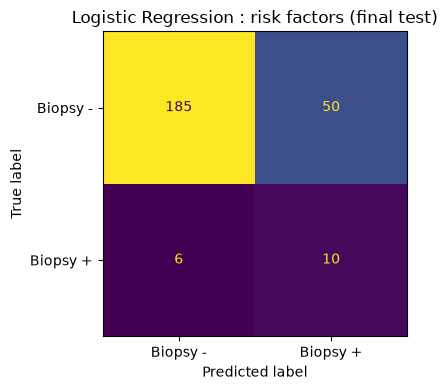

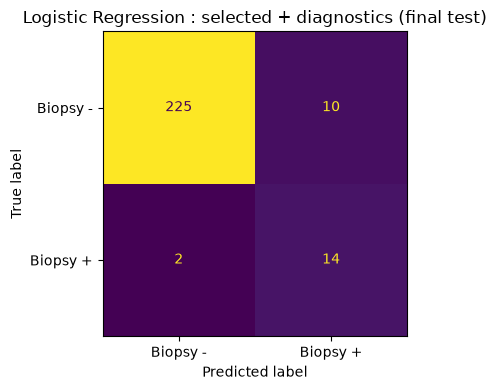

In [22]:
def plot_final_confusion_matrix(cm, title, filename):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Biopsy -", "Biopsy +"])

    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_final_confusion_matrix(risk_cm, f"{risk_model_name} : risk factors (final test)", "final_confusion_matrix_risk.png")
plot_final_confusion_matrix(diag_cm, f"{diag_model_name} : selected + diagnostics (final test)", "final_confusion_matrix_diag.png")

The confusion matrices make the practical difference between the two scenarios particularly clear.

For **risk factors only**, the model produces **185 true negatives, 50 false positives, 6 false negatives and 10 true positives**. It detects 10 of the 16 positive biopsies, but the large number of false positives explains the low precision of 0.167. This is not reliable for a strong predictive conclusion.

For **selected + diagnostics**, the model produces **225 true negatives, 10 false positives, 2 false negatives and 14 true positives**. It detects **14 of the 16 positive biopsies** while generating relatively few false positives. This is consistent with the high recall (0.875), balanced accuracy (0.916) and MCC (0.692) reported above.

**These are the final held-out confusion matrices** : unlike the previous out-of-fold matrices, they are obtained from patients that were not used during model development.

### 10. Final PR and ROC curves

PR curves are particularly informative in this project because the positive biopsy class is rare.

ROC curves are also reported as a complementary measure of ranking performance.

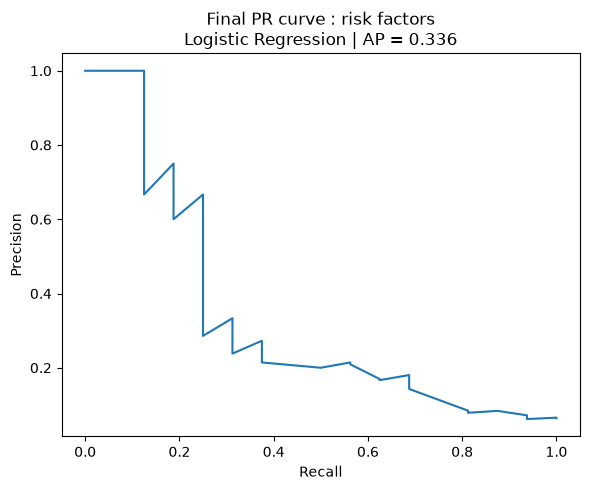

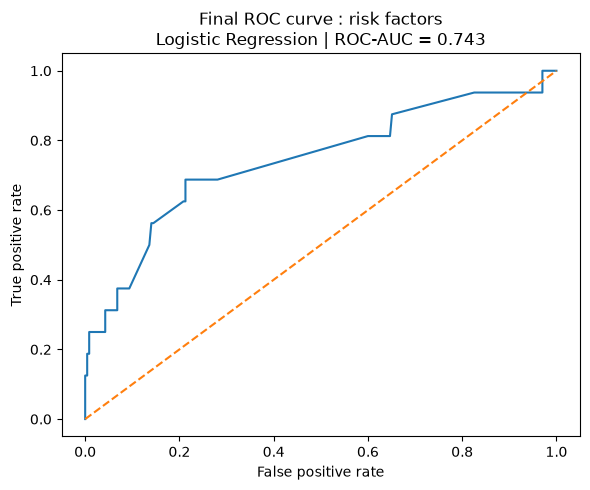

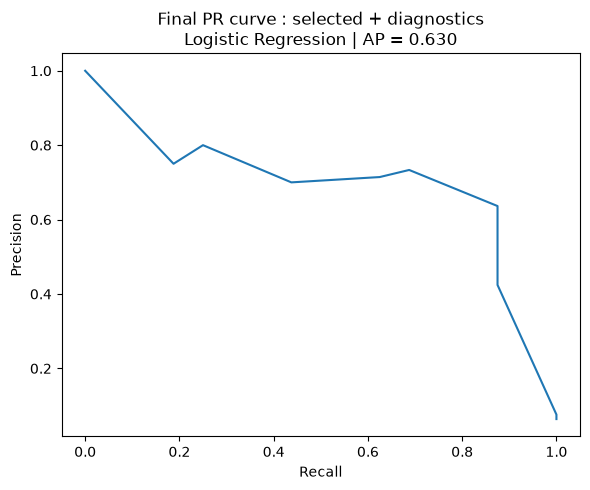

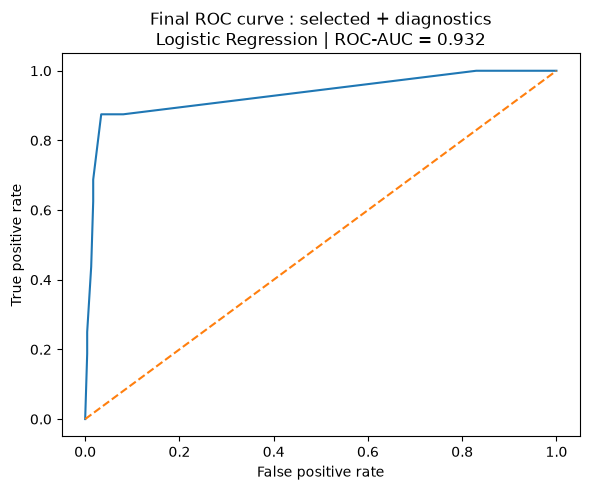

In [27]:
def plot_final_curves(y_test, probabilities, scenario_name, model_name, filename_prefix):
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    ap = average_precision_score(y_test, probabilities)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Final PR curve : {scenario_name}\n" f"{model_name} | AP = {ap:.3f}")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{filename_prefix}_pr_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"Final ROC curve : {scenario_name}\n" f"{model_name} | ROC-AUC = {auc:.3f}")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{filename_prefix}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_final_curves(y_risk_test, risk_test_prob, "risk factors", risk_model_name, "final_risk")
plot_final_curves(y_diag_test, diag_test_prob, "selected + diagnostics", diag_model_name, "final_diag")


The curves confirm that the **diagnostic-inclusive Logistic Regression ranks positive biopsies much more effectively** than the risk-factor-only model.

For **risk factors only**, AP is equal to 0.336 and ROC-AUC is 0.743. Although ranking is better than random, precision decreases rapidly as recall increases, which is important in this imbalanced dataset.

With **diagnostic variables, AP rises to 0.630 and ROC-AUC to 0.932**. The PR curve maintains higher precision over a broad recall range, while the ROC curve shows strong separation between the two classes.

Because positive biopsies are rare, **AP / the precision–recall curve remains the main criterion**. ROC-AUC is reported as complementary information and in this case, shouldn't be interpreted alone.

### 11. Compare nested-CV expectations with final test performance

A held-out test score can differ from the nested-CV mean because the dataset is small and contains few positive cases.

The purpose of this comparison is to assess whether final test behaviour is broadly compatible with the variability already observed during cross-validation.

In [ ]:
def cv_vs_test_table(scenario, selected_model_name, lr_summary, rf_summary, test_metrics):
    summary = (lr_summary
        if selected_model_name == "Logistic Regression"
        else rf_summary)
    rows = []
    for metric in ["PR_AUC", 
                   "ROC_AUC",
                   "Recall",
                   "Precision",
                   "F1",
                   "Balanced_accuracy",
                   "MCC"]:
        rows.append({"Metric": metric,
                     "Nested_CV_mean": summary.loc[metric, "Mean"],
                     "Nested_CV_std": summary.loc[metric, "Std"],
                     "Final_test": test_metrics[metric]})
    return pd.DataFrame(rows)

risk_cv_test = cv_vs_test_table("Selected risk factors", risk_model_name, lr_risk, rf_risk, risk_test_metrics)
diag_cv_test = cv_vs_test_table("Selected + diagnostics", diag_model_name, lr_diag, rf_diag, diag_test_metrics)

print("Risk factors")
display(risk_cv_test.round(3))

print("\nSelected + diagnostics")
display(diag_cv_test.round(3))

risk_cv_test.to_csv(RESULTS_DIR / "final_cv_vs_test_risk.csv", index=False)
diag_cv_test.to_csv(RESULTS_DIR / "final_cv_vs_test_diag.csv", index=False)

Risk factors


,Metric,Nested_CV_mean,Nested_CV_std,Final_test
0,PR_AUC,0.129,0.035,0.336
1,ROC_AUC,0.613,0.096,0.743
2,Recall,0.437,0.181,0.625
3,Precision,0.102,0.039,0.167
4,F1,0.161,0.060,0.263
5,Balanced_accuracy,0.572,0.095,0.706
6,MCC,0.083,0.101,0.236



Selected + diagnostics


,Metric,Nested_CV_mean,Nested_CV_std,Final_test
0,PR_AUC,0.699,0.171,0.630
1,ROC_AUC,0.944,0.065,0.932
2,Recall,0.905,0.097,0.875
3,Precision,0.545,0.099,0.583
4,F1,0.675,0.087,0.700
5,Balanced_accuracy,0.925,0.049,0.916
6,MCC,0.674,0.090,0.692


For the **diagnostic-inclusive model**, test performance is highly consistent with the nested-CV estimates. AP decreases moderately from **0.699 ± 0.171** to **0.630**, ROC-AUC from **0.944 ± 0.065** to **0.932**, and recall from **0.905 ± 0.097** to **0.875**. Precision, F1 and MCC are even slightly higher on the held-out set. Overall, the final result falls within the variability already observed during model development.

The **risk-factor-only model** behaves differently: test performance is considerably higher than its nested-CV average (AP 0.336 vs 0.129 ± 0.035) but shouldn't be interpreted as proof of a suddenly strong model. With only 16 positive biopsies in the test set, performance estimates can vary depending on which positive cases happen to fall into the split. The repeated nested-CV results remain the more robust indication that **prediction from risk factors alone is weak and unstable**.

Therefore, the held-out evaluation reinforces the main conclusion rather than changing it : the diagnostic-inclusive approach generalizes well, whereas the risk-factor-only setting performs poorly.

## Overall interpretation

The final analysis leads to three main conclusions.

**First, model complexity is not the main determinant of performance in this dataset.** Logistic Regression and Random Forest give broadly similar results after optimization. In the risk-factor-only scenario both remain weak, in the diagnostic-inclusive scenario both become stronger.

Second, **the addition of `Hinselmann`, `Schiller` and `Citology` changes the prediction problem much more than switching from a linear to a nonlinear classifier**. The previous model-interpretation analyses showed that `Schiller` is particularly influential, with `Hinselmann` and `Citology` also contributing to prediction. These variables are screening tests that are much closer to the biopsy outcome than risk factors.

Third, **Logistic Regression is retained as the final approach** because it has the highest mean nested-CV AP / PR-AUC in both scenarios, provides very high recall in the diagnostic-inclusive setting, and achieves performance comparable to Random Forest while remaining easier to interpret and substantially simpler.

The final diagnostic-inclusive Logistic Regression generalizes well to the held-out test set, whereas the risk-factor-only model remains too unstable and imprecise.

# Final conclusion

After benchmarking several supervised-learning methods, Logistic Regression and Random Forest were investigated in depth. Hyperparameters were optimized using nested cross-validation, and the final comparison was performed before the held-out test set was accessed.

In the **risk-factor-only scenario**, both optimized models showed limited predictive performance. Logistic Regression reached a mean nested-CV AP / PR-AUC of **0.129 ± 0.035**, compared with **0.119 ± 0.034** for Random Forest. Increasing model flexibility didn't compensate for the limited predictive signal contained in the selected risk factors.

In the **diagnostic-inclusive scenario**, performance improved remarkably. Logistic Regression reached a mean AP / PR-AUC of **0.699 ± 0.171**, compared with **0.685 ± 0.167** for Random Forest. Random Forest achieved somewhat higher precision, F1 and MCC, whereas Logistic Regression achieved higher recall and slightly higher AP / PR-AUC. Given the small performance differences, overlapping variability and the greater interpretability of the linear model, **Logistic Regression was selected as the final analytical approach**.

After all modelling choices were frozen, the diagnostic-inclusive Logistic Regression was evaluated once on the held-out test set using a training-derived threshold of **0.58**. The results obtained are consistent with the variability observed during nested cross-validation and support good internal generalization.

From a biological perspective, the project shows that the available risk factors alone contain limited information for predicting biopsy outcome, whereas diagnostic screening variables carry stronger predictive information. The diagnostic-inclusive model should therefore not be interpreted as a model of cervical-cancer risk, nor as a causal model. It predicts biopsy outcome partly from tests that are already clinically close to that outcome.

**Overall, the most appropriate approach for this dataset is an L2-regularized, class-weighted Logistic Regression using the selected diagnostic-inclusive feature set, because it provides a strong compromise between predictive performance, sensitivity, stability, simplicity and interpretability.**

The main limitations remain the small number of positive cases, strong class imbalance, assumptions made during missing-value handling, and the absence of an independent external cohort.

### Key methodological message

**The strongest conclusion of this project is that adding diagnostically relevant information matters far more than increasing algorithmic complexity.**

The final model was chosen from nested cross-validation on the training data, its threshold was frozen from out-of-fold training predictions, and the held-out test set was then used only once for final evaluation.
